#Homework 4 - Sequence Models

Projects in AI & ML, Spring 2026

Barbara Kotlan

3/9/2026

#Dataset

IMDB Movie Review Dataset

Link - https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Classification - Predict whether a movie review is positive or negative sentiment

Instances - 50,000 (A subset of data was used for training due to computational constraints)


Why Sequential Model:
A movie review is a chunk of text, which is naturally sequential. The order of the words in the text affects the meaning. A traditional machine learning model would not be able to capture these relationships, therefore, a sequential model is needed. Sequential models are able to understand more context and dependenceis between words.

Model:
I have chosen TensorFlow with Keras to build a Recurrent Neural Network model.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
    "IMDB Dataset.csv",
    pandas_kwargs={"encoding": "latin-1"}
)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


#Task 2

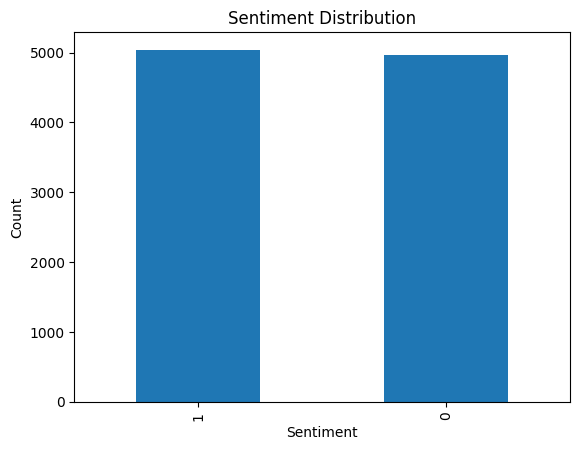

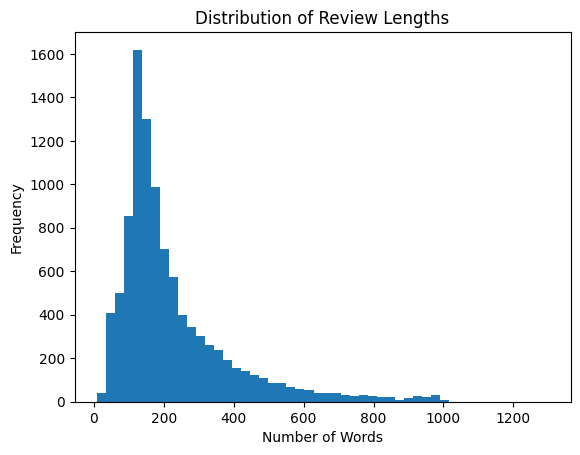

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import re

#preprosessing
df = df.sample(10000, random_state=42)

df['sentiment'] = df['sentiment'].map({"positive": 1, "negative": 0})

texts = []
for review in df['review']:
  review = review.lower()
  review = re.sub(r"<.*?>", "", review)
  review = re.sub(r"[^\w\s]", "", review)
  texts.append(review)

max_words = 5000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

X = pad_sequences(sequences, maxlen=max_len)
y = df['sentiment'].values


#visualizations
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

review_lengths = [len(s.split()) for s in texts]
plt.hist(review_lengths, bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

#Part 1
I implemented a RNN with TensorFlow and Keras API. It has three main layers, embedding, simple RNN layer, and dense output layer.
The embedding layer converts each tokenized word into a dense vector representation.
The simple RNN layer has 64 hidden units. It processes the input sequence and has a hidden state that captures comext from previous words. It also has the tanh activation function which is for learning nonlinear relationships.
The dense output layer is fully connected with a sigmoid activation function. This outputs a probability between 0 and 1, which is the predicted sentiment.


I used accuracy as the main performance metric. Accuracy is the number of correct predictions over total predictions. I looked at both training and validation accuracy during training, as well as accuracy for the final test set.


In [ ]:
#Part 1
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = keras.Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SimpleRNN(32, activation="tanh"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy: {:.3f}".format(test_accuracy))

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.5494 - loss: 0.6843 - val_accuracy: 0.6167 - val_loss: 0.6383
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.8350 - loss: 0.4328 - val_accuracy: 0.6720 - val_loss: 0.6405
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.9644 - loss: 0.1513 - val_accuracy: 0.7533 - val_loss: 0.5951
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9971 - loss: 0.0303 - val_accuracy: 0.7620 - val_loss: 0.6260
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.9999 - loss: 0.0072 - val_accuracy: 0.7700 - val_loss: 0.6874
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7729 - loss: 0.6754
Test Accuracy: 0.770


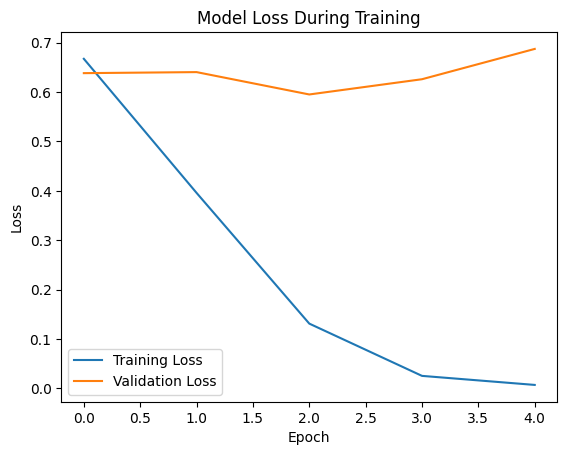

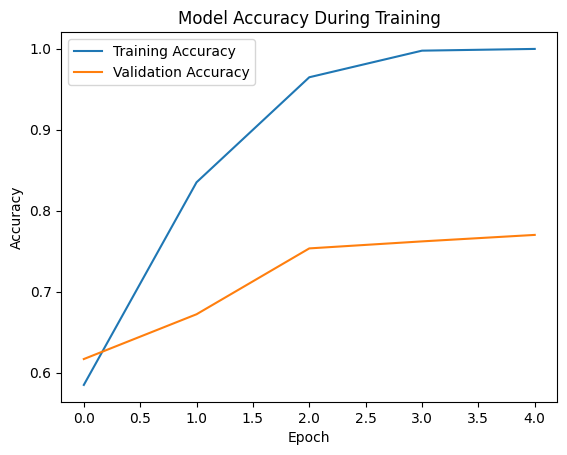

In [ ]:
#visualization
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Model Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Part 2
I implemented a LSTM which replaces the simple RNN layer. The LSTM is designed to better capture dependencies in sequential data. This layer uses internal sigmoid gates with a tanh activation functions to control information flow.


In [ ]:
#Part 2
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU

#LSTM
model_lstm = keras.Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

lstm_loss, lstm_accuracy = model_lstm.evaluate(X_test, y_test)

print("LSTM Test Accuracy: {:.3f}".format(lstm_accuracy))



Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.6405 - loss: 0.6181 - val_accuracy: 0.8180 - val_loss: 0.4128
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.8855 - loss: 0.2943 - val_accuracy: 0.8400 - val_loss: 0.3813
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - accuracy: 0.9202 - loss: 0.2179 - val_accuracy: 0.8427 - val_loss: 0.4116
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 34s 113ms/step - accuracy: 0.9480 - loss: 0.1446 - val_accuracy: 0.8387 - val_loss: 0.4166
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 38s 101ms/step - accuracy: 0.9745 - loss: 0.0864 - val_accuracy: 0.8253 - val_loss: 0.5580
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8274 - loss: 0.5143
LSTM Test Accuracy: 0.817


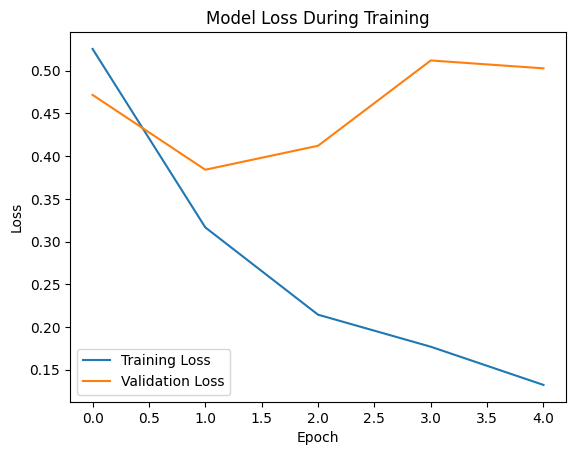

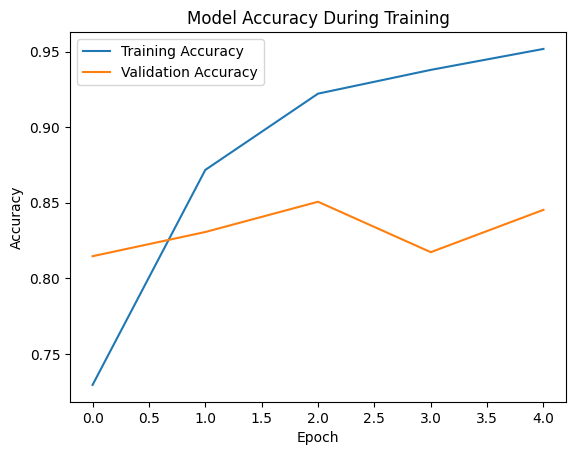

In [ ]:
#visualization
plt.plot(history_lstm.history['loss'], label="Training Loss")
plt.plot(history_lstm.history['val_loss'], label="Validation Loss")
plt.title("Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history_lstm.history['accuracy'], label="Training Accuracy")
plt.plot(history_lstm.history['val_accuracy'], label="Validation Accuracy")
plt.title("Model Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

I implemented a GRU which replaces the simple RNN layer. This is similar to a LSTM, but a bit more simple. It uses update and reset gates from information control.

In [ ]:
#GRU
model_gru = keras.Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    GRU(32),
    Dense(1, activation="sigmoid")
])

model_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

gru_loss, gru_accuracy = model_gru.evaluate(X_test, y_test)

print("GRU Test Accuracy: {:.3f}".format(gru_accuracy))



Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 134ms/step - accuracy: 0.6129 - loss: 0.6374 - val_accuracy: 0.7987 - val_loss: 0.4333
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 29s 134ms/step - accuracy: 0.8736 - loss: 0.3185 - val_accuracy: 0.8220 - val_loss: 0.3854
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 129ms/step - accuracy: 0.9186 - loss: 0.2194 - val_accuracy: 0.8273 - val_loss: 0.4034
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 132ms/step - accuracy: 0.9434 - loss: 0.1538 - val_accuracy: 0.8307 - val_loss: 0.4102
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.9673 - loss: 0.1029 - val_accuracy: 0.8347 - val_loss: 0.4778
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8517 - loss: 0.4515
GRU Test Accuracy: 0.839


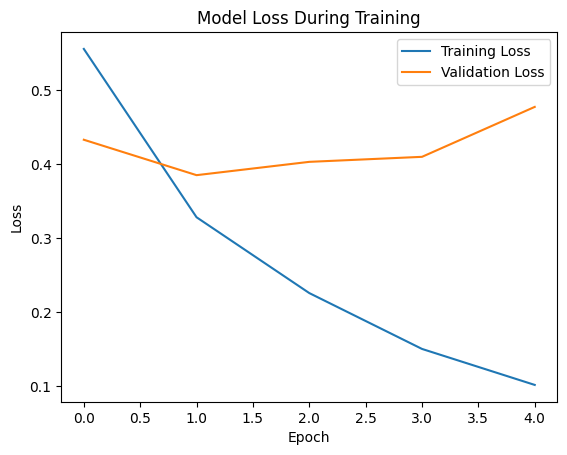

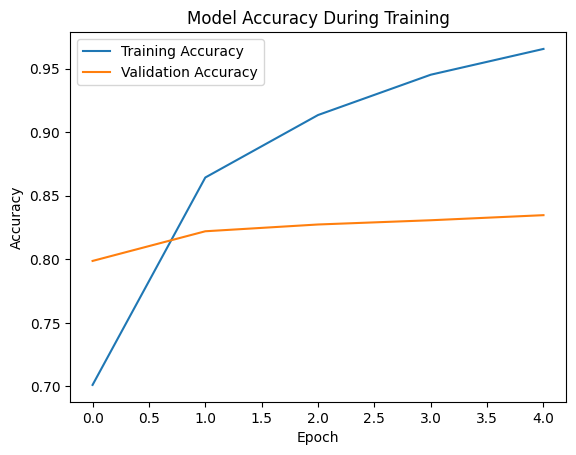

In [ ]:
#visualization
plt.plot(history_gru.history['loss'], label="Training Loss")
plt.plot(history_gru.history['val_loss'], label="Validation Loss")
plt.title("Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history_gru.history['accuracy'], label="Training Accuracy")
plt.plot(history_gru.history['val_accuracy'], label="Validation Accuracy")
plt.title("Model Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Model Comparison

Basic RNN: 0.773 Accuracy, shortest run time

LSTM: 0.825 Accuracy, middle run time

GRU: 0.816 Accuracy, longest run time

The LSTM and GRU models had a generally higher accuracy compared to the basic model. The LSTM was the highest accuracy out of the three.

The basic RNN has a vanishing gradient problem. This is during backpropagation, where gradients can become small. It makes it hard for the network to learn relationships for words that are far apart in a sequence.

The LSTM solves this issue with a memory cell and gating mechanism. A forget gate chooses information to be disregarded, while an input and output gate chooses what to store/use. This extra complexity explains the longer run time as well.

The GRU network is a simpler version of the LSTM. It combines all gates into two main ones. It reduces paramaters, which may be the reason for a slightly lower accuracy. It is still able to capture more dependencies than the basic RNN. The training time might be from batch processing, even though theoretically it should be less due to the simplicity.

#Part 3

Yes, a traditional neural network can be used to solve such a problem. However, it is not ideal for sequential data, like the text in this dataset. Feed-forward networks do not account for order of elements, which makes it inaffective.

If such a NN is attempted, the text data would need to be converted into a different representation. One option is TF-IDF, which weights the words based on their frequency. Another is bag of words, which is a vector representing word frequency. These two options do not keep the sequential structure of the text, especially when having two similar sentences but one is negative.

Recurrent neural networks are much better suited, allowing them to capture relationships with context sequentially.  




#Task 3

Part 1

I choose FastText embeddings for my pre-trained model. This is because it is pre-trained and loads fast with Gensim. It can also easily handle OOV, even with made-up words. It provides dense vector representation that capture similarity. Word2Vec is more complex to load, and BERT is more powerful but also a lot slower and heavier. GloVe is not good with OOV, as well as taking a while to load a huge file.

In [ ]:
!pip install gensim
import gensim.downloader as api
import numpy as np

print("Loading FastText embeddings...")
model = api.load("fasttext-wiki-news-subwords-300")  # ~1.5GB, optimized in Gensim
print("FastText embeddings loaded!")

def get_embedding(word, model, embedding_dim=300):
    return model[word]

In [3]:
word1 = input("Enter first word: ").strip().lower()
word2 = input("Enter second word: ").strip().lower()

embedding1 = get_embedding(word1, model)
embedding2 = get_embedding(word2, model)

print("Embedddin for '{}':\n{}".format(word1, embedding1))
print("Embedddin for '{}':\n{}".format(word2, embedding2))


Enter first word: couch
Enter second word: coffee
Embedddin for 'couch':
[-0.06262    0.052454  -0.025855   0.11988   -0.0021673 -0.11879
  0.011047  -0.1398    -0.10798    0.083384  -0.17318   -0.0482
  0.022363  -0.02634   -0.060783  -0.0055888  0.022727  -0.012443
  0.073769  -0.069795  -0.076449  -0.049694   0.021151   0.035468
  0.065763  -0.043843   0.032986   0.078869  -0.0648    -0.016848
  0.057317  -0.11658    0.021954   0.024363  -0.032087  -0.071887
  0.047569  -0.041533   0.023117   0.03171   -0.066313  -0.1699
  0.0076101  0.057223  -0.020806   0.047295   0.063629  -0.016778
 -0.065681   0.021848   0.11774   -0.053297   0.018555   0.031838
 -0.094431  -0.0058493 -0.062493  -0.037565  -0.088978  -0.056638
 -0.058823  -0.035684   0.19067    0.045918   0.0057213  0.0059091
 -0.017584   0.006282  -0.098545  -0.041094   0.076269   0.046066
  0.075623   0.031636  -0.022865  -0.036415   0.0022516 -0.025925
  0.0083179 -0.050039  -0.012617  -0.1921     0.090456   0.06264
 -0.0535

In [9]:
#Part 2

def cosine_similarity(vec1, vec2):
  if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
    return 0.0
  return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

word_pairs = [
    ("king", "queen"),
    ("chair", "table"),
    ("car", "bus"),
    ("cat", "dog"),
]

for w1, w2 in word_pairs:
  vec1 = get_embedding(w1, model)
  vec2 = get_embedding(w2, model)
  sim = cosine_similarity(vec1, vec2)
  print("Cosine similarity between '{}' and '{}': {:.3f}".format(w1, w2, sim))


Cosine similarity between 'king' and 'queen': 0.770
Cosine similarity between 'chair' and 'table': 0.507
Cosine similarity between 'car' and 'bus': 0.634
Cosine similarity between 'cat' and 'dog': 0.750


Cosine similarity measures the angle between two vectors. For word embeddings, it captures the semantic similarity between words, regardless of their magnitudes. This is useful when working with different words with similar meanings.

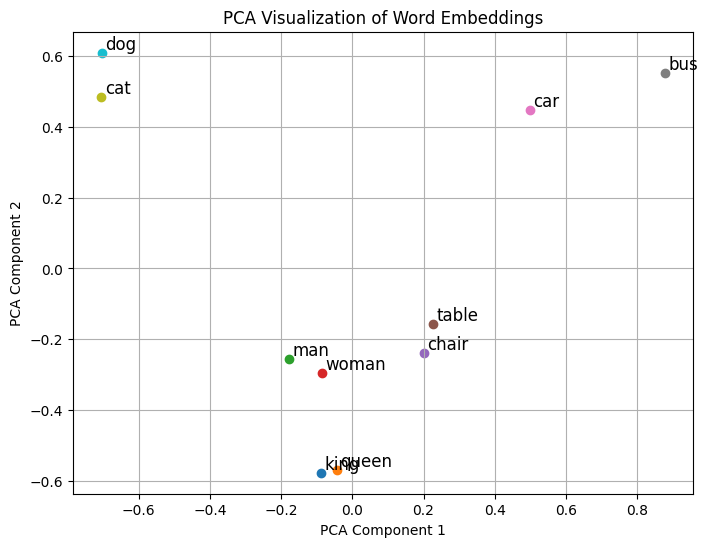

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words_to_plot = ["king", "queen", "man", "woman", "chair", "table", "car", "bus", "cat", "dog"]
vectors = np.array([get_embedding(w, model) for w in words_to_plot])

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
for i, word in enumerate(words_to_plot):
    x, y = vectors_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word, fontsize=12)
plt.title("PCA Visualization of Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

In [12]:
#Part 3
def euclidean_distance(vec1, vec2):
  return np.linalg.norm(vec1 - vec2)

def semantic_novelty(vec1, vec2):
  return euclidean_distance(vec1, vec2) * (1 - cosine_similarity(vec1, vec2))

def compare_words(w1, w2, model, metric="cosine"):
  vec1 = get_embedding(w1, model)
  vec2 = get_embedding(w2, model)

  if metric == "cosine":
    return cosine_similarity(vec1, vec2)
  elif metric == "euclidean":
    return euclidean_distance(vec1, vec2)
  elif metric == "novelty":
    return semantic_novelty(vec1, vec2)
  else:
    raise ValueError("Metric must be 'cosine', 'euclidean', or 'novelty'")

word_pairs = [
    ("cat", "dog"),
    ("cat", "lion"),
    ("cat", "table"),
    ("king", "queen"),
    ("king", "chair")
]

metrics = ["cosine", "euclidean", "novelty"]

for metric in metrics:
    print(f"\n--- Metric: {metric} ---")
    for w1, w2 in word_pairs:
        score = compare_words(w1, w2, model, metric)
        print(f"{w1} vs {w2}: {score:.3f}")


--- Metric: cosine ---
cat vs dog: 0.750
cat vs lion: 0.493
cat vs table: 0.348
king vs queen: 0.770
king vs chair: 0.366

--- Metric: euclidean ---
cat vs dog: 1.062
cat vs lion: 1.430
cat vs table: 1.478
king vs queen: 0.761
king vs chair: 1.245

--- Metric: novelty ---
cat vs dog: 0.265
cat vs lion: 0.725
cat vs table: 0.964
king vs queen: 0.175
king vs chair: 0.789


For my own metric, I created a semantic novelty which is the euclidian distance multiplied by the inverse of the cosine similarity. A higher values means the values are more dissimilar. It is able to capture the directional similarity from cosine and also the magnitude from the euclidean distance.

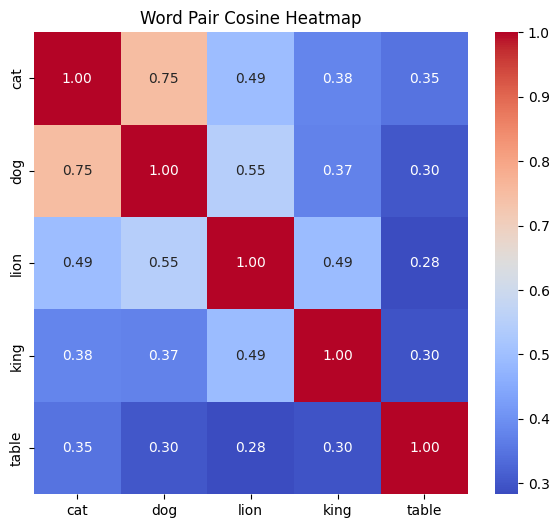

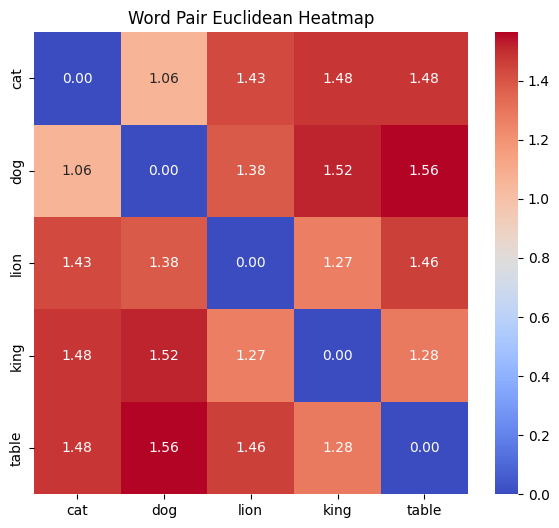

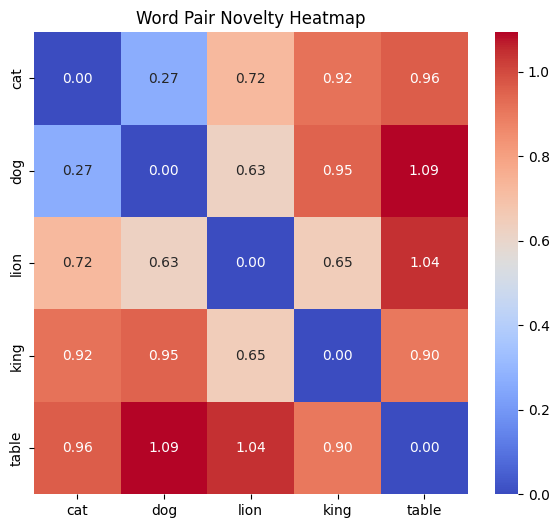

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

words = ["cat", "dog", "lion", "king", "table"]

for metric in metrics:
  matrix = np.zeros((len(words), len(words)))
  for i, w1 in enumerate(words):
      for j, w2 in enumerate(words):
          matrix[i, j] = compare_words(w1, w2, model, metric)

  plt.figure(figsize=(7,6))
  sns.heatmap(matrix, xticklabels=words, yticklabels=words, annot=True, fmt=".2f", cmap="coolwarm")
  plt.title(f"Word Pair {metric.capitalize()} Heatmap")
  plt.show()


In [15]:
target_word = "cat"
other_words = ["dog", "lion", "table", "apple"]

for metric in metrics:
    scores = {w: compare_words(target_word, w, model, metric) for w in other_words}

    if metric == "cosine":
        sorted_words = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    else:
        sorted_words = sorted(scores.items(), key=lambda x: x[1])

    print("\nRanking relative to '{}' using {}:".format(target_word, metric))
    for w, score in sorted_words:
        print("{}: {:.3f}".format(w, score))


Ranking relative to 'cat' using cosine:
dog: 0.750
lion: 0.493
apple: 0.398
table: 0.348

Ranking relative to 'cat' using euclidean:
dog: 1.062
lion: 1.430
table: 1.478
apple: 1.479

Ranking relative to 'cat' using novelty:
dog: 0.265
lion: 0.725
apple: 0.890
table: 0.964
